

## Рабочая тетрадь №6

## Задание:

### 1. Для $ 2 $ классов в $ R^2 $ найдите с помощью собственных функций:
1. Уравнение разделяющей прямой;
2. Отступы (margin) для каждого объекта.


In [1]:
import numpy as np

def get_line_and_margins(X, y):
   
   
    m1 = np.mean(X[y == -1], axis=0)
    m2 = np.mean(X[y == 1], axis=0)
    
   
    w = m2 - m1
   
    x_center = (m1 + m2) / 2
   
    b = -np.dot(w, x_center)
    

    w_norm = w / np.linalg.norm(w)
    b_norm = b / np.linalg.norm(w)
    
    margins = y * (np.dot(X, w_norm) + b_norm)
    
    return w_norm, b_norm, margins


X_example = np.array([[1, 2], [2, 1], [8, 9], [9, 8]])
y_example = np.array([-1, -1, 1, 1])

w, b, m = get_line_and_margins(X_example, y_example)

print(f"Уравнение прямой: {w[0]:.2f}*x1 + {w[1]:.2f}*x2 + {b:.2f} = 0")
print("Отступы объектов:", np.round(m, 2))

Уравнение прямой: 0.71*x1 + 0.71*x2 + -7.07 = 0
Отступы объектов: [4.95 4.95 4.95 4.95]


### 2. Для $ 3 $ классов с помощью собственных функций:
1. Постройте классификаторы;
2. Классифицируйте точку;
3. Визуализируйте резльтаты.

Точка относится к группе №0


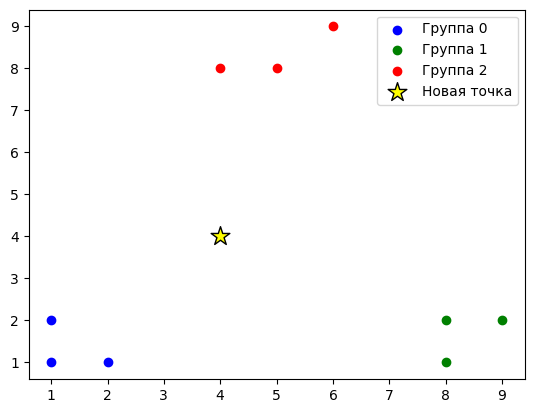

In [3]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([[1,1], [2,1], [1,2], [8,1], [9,2], [8,2], [5,8], [6,9], [4,8]])
y = np.array([0,0,0, 1,1,1, 2,2,2]) 

centroids = {i: np.mean(X[y == i], axis=0) for i in range(3)}


def simple_predict(point, centers):
    
    dists = {cls: np.linalg.norm(point - ctr) for cls, ctr in centers.items()}
    
    return min(dists, key=dists.get)


test_p = np.array([4, 4])
result = simple_predict(test_p, centroids)
print(f"Точка относится к группе №{result}")


colors = ['blue', 'green', 'red']
for i in range(3):
    plt.scatter(X[y==i, 0], X[y==i, 1], c=colors[i], label=f'Группа {i}')

plt.scatter(test_p[0], test_p[1], c='yellow', s=200, marker='*', edgecolors='black', label='Новая точка')
plt.legend()
plt.show()

### 3. Дана выборка $ 2 $ классов. С помощью собственных функций:
1. Запишите функцию правдоподобия для модели $ P(y=1|x) = \sigma(w_0 + w_1x_1 + w_2x_2) $;
2. Выведите градиент логарифмического правдоподобия.

In [12]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def get_predictions(X, w):
   
    z = np.dot(X, w)
    return sigmoid(z)

def get_log_likelihood(X, y, w):

    probs = get_predictions(X, w)
    eps = 1e-15

    likelihood = np.sum(y * np.log(probs + eps) + (1 - y) * np.log(1 - probs + eps))
    return likelihood

def get_gradient(X, y, w):
    probs = get_predictions(X, w)
    error = y - probs
    return np.dot(X.T, error)


X_data = np.array([
    [1, 0.2, 0.8], 
    [1, 0.7, 0.1], 
    [1, 0.9, 0.9]  
])
y_data = np.array([0, 1, 1]) 
weights = np.zeros(3) 

print(f"Логарифмическое правдоподобие: {get_log_likelihood(X_data, y_data, weights):.4f}")
print(f"Градиент : {get_gradient(X_data, y_data, weights)}")

Логарифмическое правдоподобие: -2.0794
Градиент : [0.5 0.7 0.1]


### 4. Для модели $ w_{t+1} = w_t + η(y_i - σ(w_t^T x_i))x_i $ выполните $ n $ итерации для точки с $ y $ и $ \eta $ с помощью собственных функций. Визуализируйте.

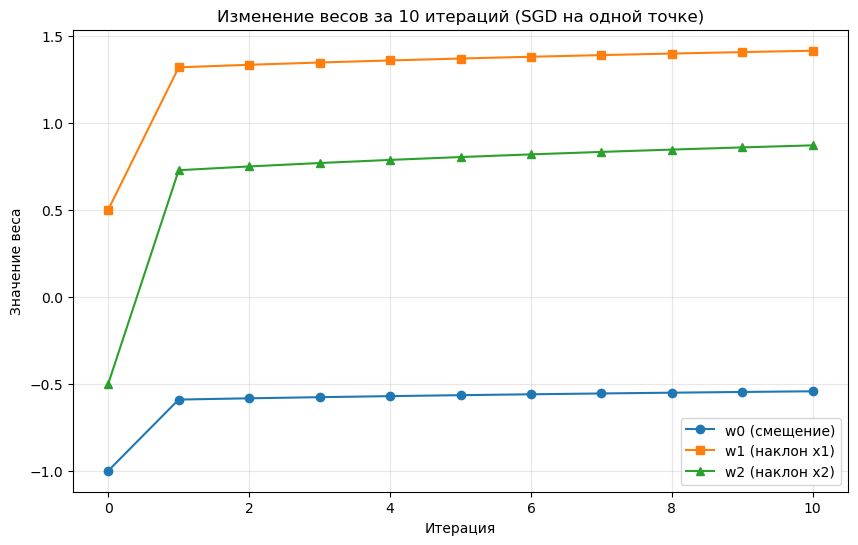

Вероятность после обучения: 0.9925


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_on_point(x_i, y_i, w_start, eta, n_iterations):
    
    w_history = [w_start.copy()]
    w = w_start.copy()
    
    for _ in range(n_iterations):
    
        prediction = sigmoid(np.dot(w, x_i))
        
       
        w = w + eta * (y_i - prediction) * x_i
        w_history.append(w.copy())
        
    return np.array(w_history)


point = np.array([1, 2, 3]) 
y_true = 1
initial_weights = np.array([-1.0, 0.5, -0.5])
learning_rate = 0.5


history = train_on_point(point, y_true, initial_weights, learning_rate, 10)


plt.figure(figsize=(10, 6))
steps = np.arange(len(history))

plt.plot(steps, history[:, 0], label='w0 (смещение)', marker='o')
plt.plot(steps, history[:, 1], label='w1 (наклон x1)', marker='s')
plt.plot(steps, history[:, 2], label='w2 (наклон x2)', marker='^')

plt.title(f"Изменение весов за {len(steps)-1} итераций (SGD на одной точке)")
plt.xlabel("Итерация")
plt.ylabel("Значение веса")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


final_prob = sigmoid(np.dot(history[-1], point))
print(f"Вероятность после обучения: {final_prob:.4f}")

### 5. Даны линейно разделимые данные для $ 2 $ классов. Найдите и визуализируйте с помощью собственных функций:

- Оптимальную разделяющую гиперплоскость;
- Ширину зазора (margin).

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def get_optimal_hyperplane(X, y):
    
    m1 = np.mean(X[y == -1], axis=0)
    m2 = np.mean(X[y == 1], axis=0)
    
    w = m2 - m1

    center = (m1 + m2) / 2
    b = -np.dot(w, center)
    

    margin = 2 / np.linalg.norm(w)
    return w, b, margin


X = np.array([[1, 2], [2, 1], [4, 5], [5, 4]])
y = np.array([-1, -1, 1, 1])
w, b, margin = get_optimal_hyperplane(X, y)

print(f"Ширина зазора (Margin): {margin:.4f}")



Ширина зазора (Margin): 0.4714


### 6. Для модели $ P(y=1|x) = \sigma(w_0 + w_1x_1 + w_2x_2) $ рассчитайте вероятности для $ n $ точек с помощью собственных функций.

In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_probabilities(X, w):

    z = np.dot(X, w)
    return sigmoid(z)


X_points = np.array([
    [1, 0.5, 0.2],
    [1, 1.5, 2.5],
    [1, 4.0, 5.0],
    [1, 0.1, 0.1]
])


weights = np.array([-2.5, 0.8, 0.4]) 

probs = predict_probabilities(X_points, weights)

for i, p in enumerate(probs):
    cls = 1 if p >= 0.5 else 0
    print(f"Точка {i+1}: Вероятность = {p:.4f} -> Класс {cls}")

Точка 1: Вероятность = 0.1171 -> Класс 0
Точка 2: Вероятность = 0.4256 -> Класс 0
Точка 3: Вероятность = 0.9370 -> Класс 1
Точка 4: Вероятность = 0.0847 -> Класс 0


### 7. Даны веса для $ n $ классов и $ b $. Для точки $ x $ с помощью собственных функций вычислите логиты, примените Softmax.

In [26]:
import numpy as np

def calculate_logits(x, weights, bias):

    logits = np.dot(weights, x) + bias
    return logits

def softmax(logits):

    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)


x_point = np.array([1.0, 2.0])


W = np.array([
    [0.5, -0.1],  
    [-0.2, 0.8],  
    [0.7, 0.3]    
])
b = np.array([0.1, 0.5, -0.2])

logits = calculate_logits(x_point, W, b)
print(f"Логиты: {logits}")


probabilities = softmax(logits)
print(f"Вероятности: {probabilities}")
print(f"Сумма вероятностей: {np.sum(probabilities):.1f}")

Логиты: [0.4 1.9 1.1]
Вероятности: [0.13341442 0.59792194 0.26866364]
Сумма вероятностей: 1.0
